Import all the libraries

In [63]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated, Literal
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from langchain_groq import ChatGroq
import operator

In [64]:
load_dotenv()

True

In [65]:
model = ChatGroq(model="llama-3.3-70b-versatile")

Testing the structured outputs

In [66]:
class Sentiment(BaseModel):
    
    sentiment: Annotated[str, Field(description="The sentiment of the review, either 'positive' or 'negative'.")]

In [67]:
structured_model = model.with_structured_output(Sentiment)
review = "The product was fantastic! I loved using it every day and it exceeded my expectations."
prompt = f"Determine the sentiment of the following review:\n{review}"
response = structured_model.invoke(prompt)
print(response)  

sentiment='positive'


In [68]:
response.sentiment

'positive'

Defining all the states of the workflow

In [69]:
class ReviewState(TypedDict):

    review: str
    sentiment: str
    diagnosis: dict
    response: str

Defining Structure for the Diagnosis

**Diagnosis** provide three aspects with the help of LLMs and consider them to generate response.

The Three following aspects are:
1. Issue Type - The type of issue the customer is talking about in the review like product damaged, bugs in the application, etc.
2. Tone - This help to get the emotions of the customer behind the review like angry, happy, frustrated, excited, etc.
3. Urgency - This tells that how much urgent the customer behind the review for the issue being solved by the liable company.

Note: The diagnosis will run only if **sentiment of a review is found to be negative** else it simply provide the positive response to the review which is positive.

In [70]:
class DiagnosisSchema(BaseModel):
    
    issue_type: Annotated[str, Field(description="The main issue type identified in the review.")]
    tone: Annotated[str, Field(description="The tone of the review, e.g., angry, frustated, satisfied, neutral, happy, etcs.")]
    urgency: Annotated[str, Field(description="The urgency level of the review, e.g., high, medium, low.")]

In [71]:
diagnosis_structured_model = model.with_structured_output(DiagnosisSchema)

Defining nodes i.e. python functions for the graph

In [72]:
def sentiment_extraction(state: ReviewState):

    prompt = f"Determine the sentiment of the following review:\n{state['review']}"
    response = structured_model.invoke(prompt)
    sentiment_text = response.sentiment
    return {"sentiment": sentiment_text}

In [73]:
def diagnosis(state: ReviewState):

    prompt = f"""Analyze the following negative review and provide a diagnosis including the main issue type, tone, and urgency level:\n{state['review']}"""
    response = diagnosis_structured_model.invoke(prompt)
    diagnosis_dict = {
        "issue_type": response.issue_type,
        "tone": response.tone,
        "urgency": response.urgency
    }
    return {"diagnosis": diagnosis_dict}

In [74]:
def negative_sentiment_response(state: ReviewState):

    prompt = f"""Generate a thoughtful and empathetic response (to the point and not too long) to the following negative review na dits diagnosis parameters, addressing the customer's concerns:\nReview - {state['review']}\n Diagnosis - {state['diagnosis']}"""
    response = model.invoke(prompt).content
    return {"response": response}

In [75]:
def positive_sentiment_response(state: ReviewState):

    prompt = f"""Generate a warm and appreciative response (to the point and not too long) to the following positive review, thanking the customer for their feedback:\n{state['review']}"""
    response = model.invoke(prompt).content
    return {"response": response}

In [76]:
def check_sentiment(state: ReviewState) -> Literal["diagnosis", "positive_sentiment_response"]:

    if state["sentiment"].lower() == "negative":
        return "diagnosis"
    else:
        return "positive_sentiment_response"

Graph Creation

In [77]:
graph = StateGraph(ReviewState)

Adding graphs, edges and conditional edge

In [78]:
graph.add_node("sentiment_extraction", sentiment_extraction)
graph.add_node("diagnosis", diagnosis)
graph.add_node("negative_sentiment_response", negative_sentiment_response)
graph.add_node("positive_sentiment_response", positive_sentiment_response)


graph.add_edge(START, "sentiment_extraction")
graph.add_conditional_edges("sentiment_extraction", check_sentiment)
graph.add_edge("diagnosis", "negative_sentiment_response")
graph.add_edge("negative_sentiment_response", END)
graph.add_edge("positive_sentiment_response", END)

Compilation of the graph

In [79]:
workflow = graph.compile()

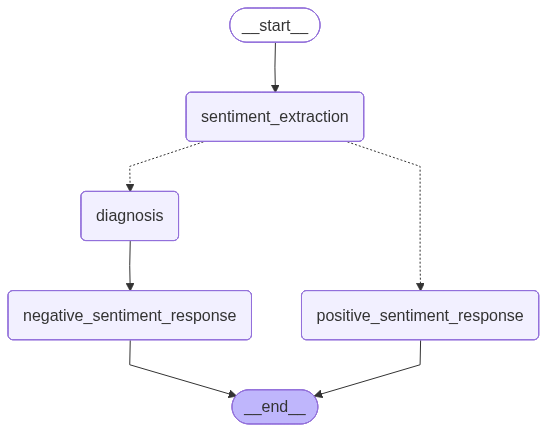

In [80]:
workflow

Execution of the graph with different reviews

In [ ]:
import json

initial_state1 = {
    "review": "The product was terrible! It broke on the first day and customer service was unhelpful."
}
response = workflow.invoke(initial_state1)

#the below function just print the response in a good readable format however if you simply put print(response) you will get the same info in a single line.
def pretty_print_state(state):
    for k, v in state.items():
        print(f"{k}:")
        if isinstance(v, (dict, list)):
            print(json.dumps(v, indent=4))
        else:
            print(f"  {v}")
        print()  

pretty_print_state(response)

review:
  The product was terrible! It broke on the first day and customer service was unhelpful.

sentiment:
  negative

diagnosis:
{
    "issue_type": "product quality and customer service",
    "tone": "angry",
    "urgency": "high"
}

response:
  I'm so sorry to hear that the product broke on the first day and that our customer service didn't meet your expectations. I can understand how frustrating that must be. I'd like to make things right - can you please contact me directly so I can assist you with a replacement or refund, and also look into the issue with our customer service team to prevent this from happening again in the future?



In [82]:
initial_state2 = {
    "review": "The delivery service was slower than promised, which caused inconvenience. Tracking updates were inconsistent, and communication regarding the delay was limited. Improving coordination and timely notifications would significantly enhance the overall experience."
}
response = workflow.invoke(initial_state2)

#the below function just print the response in a good readable format however if you simply put print(response) you will get the same info in a single line.
def pretty_print_state(state):
    for k, v in state.items():
        print(f"{k}:")
        if isinstance(v, (dict, list)):
            print(json.dumps(v, indent=4))
        else:
            print(f"  {v}")
        print()  

pretty_print_state(response)

review:
  The delivery service was slower than promised, which caused inconvenience. Tracking updates were inconsistent, and communication regarding the delay was limited. Improving coordination and timely notifications would significantly enhance the overall experience.

sentiment:
  negative

diagnosis:
{
    "issue_type": "delivery issue",
    "tone": "frustrated",
    "urgency": "medium"
}

response:
  "I'm so sorry to hear that our delivery service didn't meet your expectations, causing inconvenience and frustration. I understand how important it is to receive timely updates and communication. I'll make sure to pass on your feedback to our team to improve our coordination and notification process. Can I offer you a gesture of goodwill for the delay or assist you with any further concerns?"



In [84]:
initial_state3 = {
    "review": "The software tool lacks stability and occasionally crashes during use. Some features are not intuitive and require additional guidance, which affects productivity. With better optimization and clearer documentation, the tool could become more effective and user-friendly."
}
response = workflow.invoke(initial_state3)

#the below function just print the response in a good readable format however if you simply put print(response) you will get the same info in a single line.
def pretty_print_state(state):
    for k, v in state.items():
        print(f"{k}:")
        if isinstance(v, (dict, list)):
            print(json.dumps(v, indent=4))
        else:
            print(f"  {v}")
        print()  

pretty_print_state(response)

review:
  The software tool lacks stability and occasionally crashes during use. Some features are not intuitive and require additional guidance, which affects productivity. With better optimization and clearer documentation, the tool could become more effective and user-friendly.

sentiment:
  negative

diagnosis:
{
    "issue_type": "software stability and usability",
    "tone": "neutral",
    "urgency": "medium"
}

response:
  "I'm sorry to hear that our software tool has been crashing and causing frustration with its usability. I understand how this can impact your productivity and overall experience. We take these issues seriously and are working to optimize the tool's performance and provide clearer documentation to make it more intuitive. I'd be happy to provide additional guidance and support in the meantime. Your feedback is valuable in helping us improve, and I appreciate you taking the time to share your concerns."



In [85]:
initial_state4 = {
    "review": "The online learning platform provides well-structured courses with clear explanations and practical examples. The content is easy to follow, and the user interface is smooth, making navigation simple even for first-time users. Overall, it has been a valuable resource for skill development."
}
response = workflow.invoke(initial_state4)

#the below function just print the response in a good readable format however if you simply put print(response) you will get the same info in a single line.
def pretty_print_state(state):
    for k, v in state.items():
        print(f"{k}:")
        if isinstance(v, (dict, list)):
            print(json.dumps(v, indent=4))
        else:
            print(f"  {v}")
        print()  

pretty_print_state(response)

review:
  The online learning platform provides well-structured courses with clear explanations and practical examples. The content is easy to follow, and the user interface is smooth, making navigation simple even for first-time users. Overall, it has been a valuable resource for skill development.

sentiment:
  positive

response:
  Dear valued customer,

We're thrilled to hear that our online learning platform has been a valuable resource for your skill development! Thank you for taking the time to share your positive feedback about our courses and user interface. We appreciate your kind words and are glad you found our content easy to follow and navigate. Your feedback is invaluable to us, and we're grateful for customers like you.

Best regards, [Your Name]



In [86]:
initial_state5 = {
    "review": "The customer support team was responsive and helpful throughout the interaction. Queries were addressed patiently, and the solutions provided were accurate and effective. The professionalism and positive attitude of the staff made the experience reassuring and efficient."
}
response = workflow.invoke(initial_state5)

#the below function just print the response in a good readable format however if you simply put print(response) you will get the same info in a single line.
def pretty_print_state(state):
    for k, v in state.items():
        print(f"{k}:")
        if isinstance(v, (dict, list)):
            print(json.dumps(v, indent=4))
        else:
            print(f"  {v}")
        print()  

pretty_print_state(response)

review:
  The customer support team was responsive and helpful throughout the interaction. Queries were addressed patiently, and the solutions provided were accurate and effective. The professionalism and positive attitude of the staff made the experience reassuring and efficient.

sentiment:
  positive

response:
  Dear valued customer,

We're thrilled to hear that our support team exceeded your expectations. Thank you for taking the time to share your feedback and for recognizing the efforts of our staff. We're grateful for customers like you and look forward to continuing to provide you with exceptional service.

Best regards, [Your Company]



In [87]:
initial_state6 = {
    "review": "The mobile application performs reliably with minimal lag and a clean design. Features are well-integrated and function as expected, enhancing overall usability. Regular updates show continuous improvement and commitment to user satisfaction."
}
response = workflow.invoke(initial_state6)

#the below function just print the response in a good readable format however if you simply put print(response) you will get the same info in a single line.
def pretty_print_state(state):
    for k, v in state.items():
        print(f"{k}:")
        if isinstance(v, (dict, list)):
            print(json.dumps(v, indent=4))
        else:
            print(f"  {v}")
        print()  

pretty_print_state(response)

review:
  The mobile application performs reliably with minimal lag and a clean design. Features are well-integrated and function as expected, enhancing overall usability. Regular updates show continuous improvement and commitment to user satisfaction.

sentiment:
  positive

response:
  Thank you so much for taking the time to share your positive experience with our mobile application! We're thrilled to hear that you're enjoying the clean design, reliable performance, and regular updates. Your feedback is invaluable to us, and we appreciate your recognition of our efforts to continuously improve and enhance user satisfaction.

